# Análisis y Tratamiento de Datos Faltantes: Diagnóstico e Imputación Experta



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/90_casos_estudio/datos_faltantes_imputacion.ipynb)


## Objetivos del Caso de Estudio


- **Perspectiva de Datos:** Comprender que la ausencia de un dato es información valiosa. Diferenciar matemáticamente los tres mecanismos de pérdida: **MCAR, MAR y MNAR**.
- **Diagnóstico Visual:** Utilizar la librería experta `missingno` para descubrir patrones ocultos y correlaciones en la nulidad de las variables.
- **Estrategias de Ingeniería:** Implementar y contrastar técnicas de imputación en *Pipelines* a prueba de fugas de datos: Eliminación, Imputación Simple con Indicadores, KNN Imputer y MICE (Imputación Multivariada).
- **El Cambio de Paradigma:** Demostrar cómo los algoritmos modernos basados en árboles (*Native Tree Handling*) hacen que la imputación sea obsoleta en muchos escenarios de producción.



## Prerrequisitos


- Entendimiento de *Pipelines* y prevención de *Data Leakage*. Por lo tanto;
- Haber completado: [Pipelines y Prevención de Leakage](../03_machine_learning/09_pipelines_y_prevencion_leakage.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos missingno para visualización experta de nulos
    subprocess.run(["pip", "install", "missingno"], check=True)
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## 1. Introducción: El Laboratorio de Datos (Generación Sintética)


El error más común de un analista junior es ejecutar `df.fillna(df.mean())` o `df.dropna()` sin pensar. Rellenar con la media destruye la varianza natural de los datos, y borrar filas destruye la representatividad de la muestra.

Para tratar los nulos como un Ingeniero experto, primero debemos entender **por qué** falta el dato. Existen tres mecanismos:
1. **MCAR (*Missing Completely at Random*):** El dato falta por puro azar. (Ej. Un sensor falló un milisegundo por un pico de voltaje).
2. **MAR (*Missing at Random)*:** La falta del dato depende de *otra* variable que sí tenemos. (Ej. Los hombres son menos propensos a rellenar encuestas de salud emocional. Si sabemos el género, podemos inferir el patrón de nulidad).
3. **MNAR (*Missing Not at Random*):** El caso más peligroso. El dato falta por una razón ligada al *propio valor* que falta. (Ej. Las personas con ingresos ilegales o extremadamente altos dejan la casilla de "Salario" en blanco).

### Creando nuestro "Ground Truth"


En el mundo real, nunca sabemos con certeza si un dato es MAR o MNAR porque no tenemos el dato para comprobarlo. Por ello, en este caso de estudio **creamos un dataset sintético perfecto** (nuestro *Ground Truth*) y luego le inyectamos nulos aplicando reglas estrictas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# 1. Generamos un dataset perfecto (Ground Truth)
np.random.seed(42)
n_samples = 2000

edad = np.random.normal(40, 10, n_samples)
experiencia = np.maximum(0, edad - 20 + np.random.normal(0, 3, n_samples))
horas_trabajo = np.random.normal(40, 5, n_samples)
# El ingreso depende de la experiencia y las horas
ingreso_real = 1000 + (experiencia * 150) + (horas_trabajo * 50) + np.random.normal(0, 500, n_samples)

# Target: ¿Gana más de $8000? (Clasificación Binaria)
target = (ingreso_real > 8000).astype(int)

df_clean = pd.DataFrame({
    'Edad': edad,
    'Experiencia': experiencia,
    'Horas_Trabajo': horas_trabajo,
    'Ingreso': ingreso_real,
    'Target': target
})

print("Dataset Ground Truth (Sin Nulos) creado con éxito.")

Dataset Ground Truth (Sin Nulos) creado con éxito.


### Inyectando los Mecanismos de Nulidad



Ahora, vamos a corromper nuestro dataset perfecto.



In [3]:
df_missing = df_clean.copy()

# 1. Inyección MCAR (Puro Azar) en 'Horas_Trabajo'
# Borramos el 15% de los datos tirando una moneda
mcar_mask = np.random.rand(n_samples) < 0.15
df_missing.loc[mcar_mask, 'Horas_Trabajo'] = np.nan

# 2. Inyección MAR (Depende de otra variable) en 'Experiencia'
# Borramos la experiencia condicionada a la Edad (Los mayores de 50 años olvidan ponerla el 40% de las veces)
mar_mask = (df_missing['Edad'] > 50) & (np.random.rand(n_samples) < 0.40)
df_missing.loc[mar_mask, 'Experiencia'] = np.nan

# 3. Inyección MNAR (Depende de sí misma) en 'Ingreso'
# Borramos el ingreso si el ingreso es MUY ALTO (Los ricos ocultan su salario el 60% de las veces)
mnar_mask = (df_clean['Ingreso'] > 9500) & (np.random.rand(n_samples) < 0.60)
df_missing.loc[mnar_mask, 'Ingreso'] = np.nan

print(f"Nulos inyectados:\n{df_missing.isnull().sum()}")

Nulos inyectados:
Edad               0
Experiencia      141
Horas_Trabajo    291
Ingreso           24
Target             0
dtype: int64


## 2. Detección y Visualización Experta (`missingno`)



Antes de imputar, un ingeniero audita. La librería `missingno` es el estándar de la industria para esto.



### A. Matriz de Nulidad


Nos permite ver si los nulos aparecen en bloques (fallos de sistema) o dispersos.



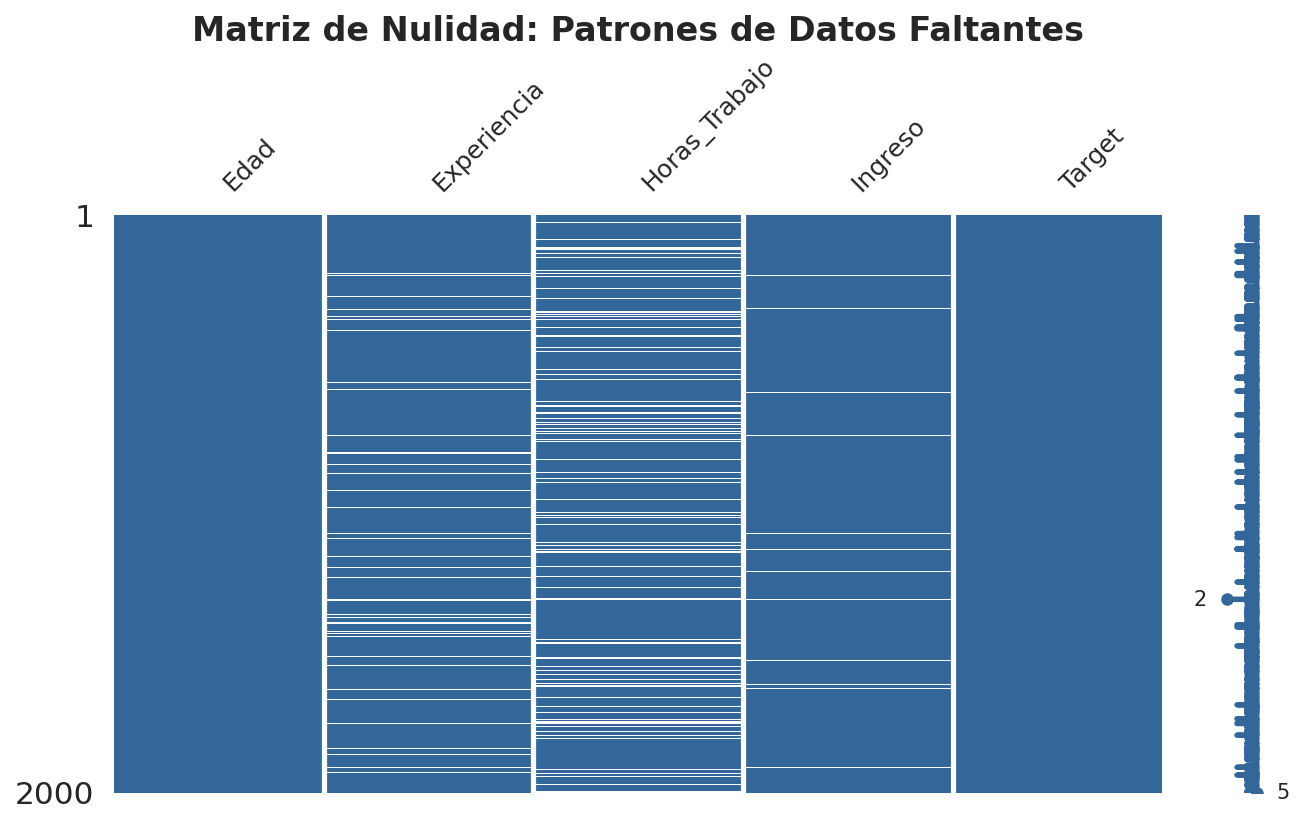

In [4]:
# Visualizamos la matriz de nulidad
msno.matrix(df_missing, figsize=(10, 5), fontsize=12, color=(0.2, 0.4, 0.6))
plt.title("Matriz de Nulidad: Patrones de Datos Faltantes", fontsize=16)
plt.show()

*Análisis:* Observar la columna `Ingreso`. Los espacios en blanco no están distribuidos uniformemente; se agrupan en ciertas filas. Esto es una pista visual de que no es puro azar (MCAR).

### B. Mapa de Calor de Correlación de Nulos


¿La ausencia de la variable A predice la ausencia de la variable B?



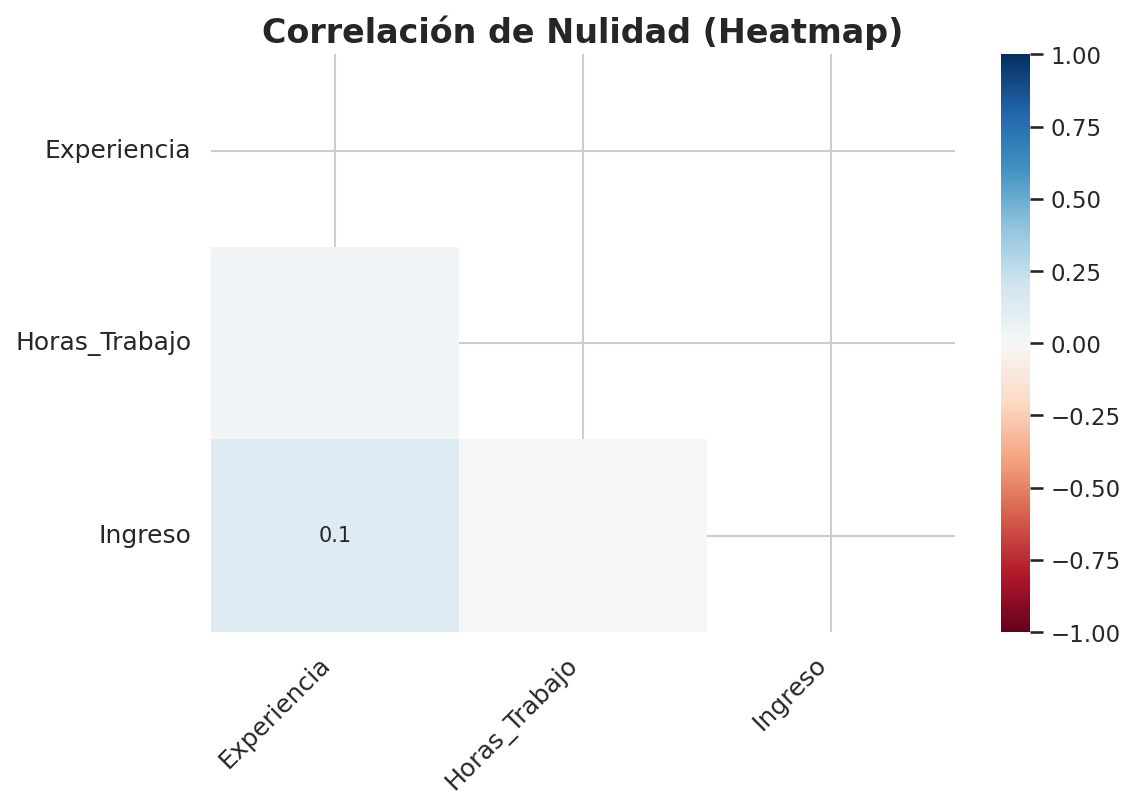

In [5]:
msno.heatmap(df_missing, figsize=(8, 5), fontsize=12)
plt.title("Correlación de Nulidad (Heatmap)", fontsize=16)
plt.show()

*Análisis:* Si tuviéramos un valor cercano a `1` entre dos variables, significaría que cuando falla un sensor, el otro también falla. En nuestro caso, las inyecciones fueron independientes, por lo que las correlaciones de nulidad son bajas.

## 3. Estrategias de Tratamiento y Evaluación (El Experimento)


Vamos a dividir nuestros datos en Train y Test.

**⚠️ Alerta:** La división debe hacerse *antes* de cualquier imputación para evitar el *Data Leakage*.

In [6]:
# Separamos Features y Target del dataset con nulos
X_miss = df_missing.drop(columns=['Target'])
y = df_missing['Target']

X_train, X_test, y_train, y_test = train_test_split(X_miss, y, test_size=0.2, random_state=42)

# También preparamos el Ground Truth para tener nuestro "Techo de Cristal" (El máximo rendimiento posible)
X_clean = df_clean.drop(columns=['Target'])
X_train_clean, X_test_clean, _, _ = train_test_split(X_clean, y, test_size=0.2, random_state=42)


Definimos un modelo base (Random Forest) y probamos 5 estrategias diferentes para lidiar con los nulos. Guardamos el *F1-Score* de cada una.



In [7]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer, KNNImputer
# Habilitamos el IterativeImputer (MICE) que es experimental en sklearn
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import seaborn as sns

resultados_f1 = {}
modelo_base = RandomForestClassifier(n_estimators=100, random_state=42)

# --- 0. El Techo de Cristal (Ground Truth) ---
# Entrenamos sobre los datos perfectos que nunca tuvieron nulos
modelo_base.fit(X_train_clean, y_train)
resultados_f1['0. Ground Truth (Perfecto)'] = f1_score(y_test, modelo_base.predict(X_test_clean))

### Estrategia A: Eliminación (*Listwise Deletion*)


Borrar las filas con nulos.

*Criterio:* Destructivo. Como inyectamos MNAR en los ingresos altos, si borramos las filas, ¡nuestro modelo nunca aprenderá a identificar a las personas ricas!



In [8]:
# Eliminamos filas con nulos solo en el Train
train_idx_no_nulos = X_train.dropna().index
X_train_drop = X_train.loc[train_idx_no_nulos]
y_train_drop = y_train.loc[train_idx_no_nulos]

modelo_base.fit(X_train_drop, y_train_drop)

# Para evaluar, lamentablemente debemos imputar el Test set (no podemos borrar filas en producción)
# Usaremos una imputación simple solo para que el modelo no falle al predecir
imputer_fallback = SimpleImputer(strategy='median').fit(X_train_drop)
resultados_f1['A. Eliminación (Dropna)'] = f1_score(y_test, modelo_base.predict(imputer_fallback.transform(X_test)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Estrategia B: Imputación Simple + Indicador de Nulidad


Rellenar con la mediana, pero agregando una columna booleana (`ingreso_fue_nulo = True/False`).

*Criterio:* Brillante y barato. Si el hecho de que falte el salario significa que la persona es rica (MNAR), el modelo usará la columna booleana `ingreso_fue_nulo == True` como una regla de decisión súper predictiva.

In [9]:
pipe_simple = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), # add_indicator es la magia
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_simple.fit(X_train, y_train)
resultados_f1['B. Mediana + Indicador'] = f1_score(y_test, pipe_simple.predict(X_test))

### Estrategia C: Imputación Basada en Distancias (KNN Imputer)


Busca a los "K" individuos más parecidos en las otras variables y promedia sus valores.


*Criterio:* Captura relaciones no lineales, pero calcular distancias en producción tiene una latencia de $O(N^2)$.

In [10]:
pipe_knn = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_knn.fit(X_train, y_train)
resultados_f1['C. KNN Imputer'] = f1_score(y_test, pipe_knn.predict(X_test))

### Estrategia D: Imputación Multivariada Iterativa (MICE)


El estándar de oro estadístico. Modela cada columna con nulos como una regresión de todas las demás columnas, iterando en *Round Robin*.



In [11]:
pipe_mice = Pipeline([
    ('imputer', IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_mice.fit(X_train, y_train)
resultados_f1['D. MICE (IterativeImputer)'] = f1_score(y_test, pipe_mice.predict(X_test))

## 4. El Cambio de Paradigma: Soporte Nativo en Árboles


**La Revelación de Ingeniería:**
Hoy en día, si se usan algoritmos modernos de *Gradient Boosting* (XGBoost, LightGBM, o `HistGradientBoostingClassifier` de Scikit-Learn), **no se necesita imputar los nulos**.

Estos algoritmos manejan los `NaN` de forma nativa. Durante el entrenamiento, cuando el árbol evalúa un corte (ej. `Edad > 40`), envía todos los registros con `Edad = NaN` a la rama izquierda, y luego a la rama derecha. Se queda con la dirección que reduzca más la función de pérdida.
Es matemáticamente superior a inventar un dato, y tiene **latencia cero** en producción.

In [12]:
# Estrategia E: Native Tree Handling
# Pasamos los datos CRUDOS con nulos directamente al modelo
modelo_nativo = HistGradientBoostingClassifier(random_state=42)
modelo_nativo.fit(X_train, y_train)
resultados_f1['E. Soporte Nativo (HistGradientBoosting)'] = f1_score(y_test, modelo_nativo.predict(X_test))

## 5. Evaluación del Impacto (Veredicto Final)



Vamos a graficar el Retorno de Inversión (ROI) de nuestras decisiones de ingeniería.



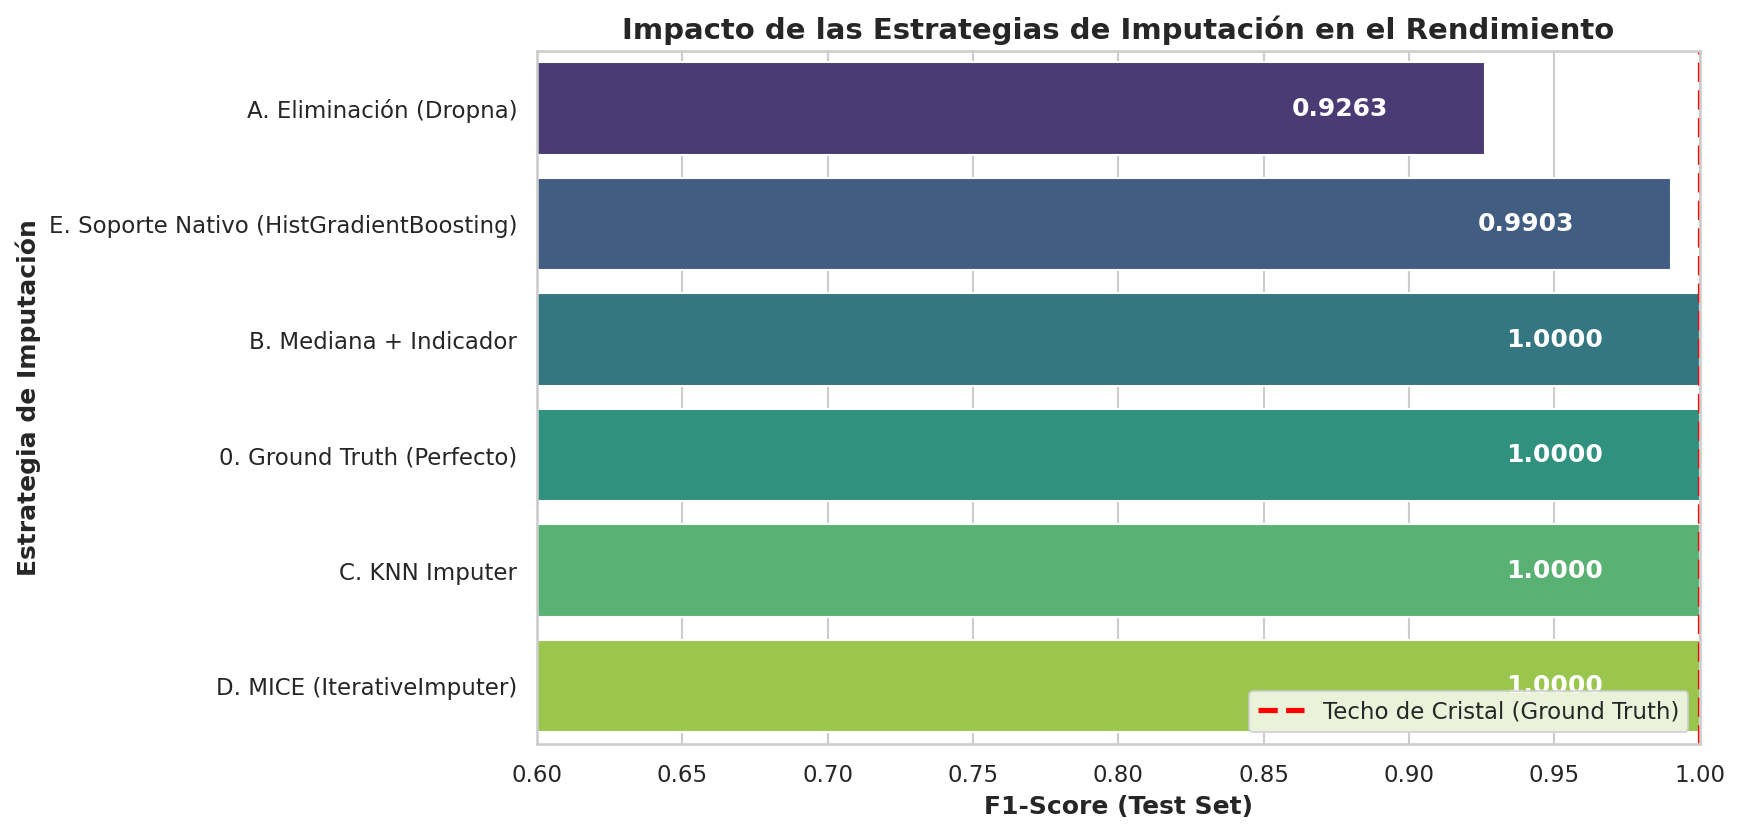

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertimos el diccionario a un DataFrame para graficar
df_resultados = pd.DataFrame(list(resultados_f1.items()), columns=['Estrategia', 'F1_Score']).sort_values(by='F1_Score', ascending=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='F1_Score', y='Estrategia', data=df_resultados, palette='viridis', hue='Estrategia', legend=False)

# Añadimos los valores en las barras
for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}', (p.get_width() - 0.05, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', color='white', fontweight='bold')

# Línea del Ground Truth
gt_score = resultados_f1['0. Ground Truth (Perfecto)']
plt.axvline(x=gt_score, color='red', linestyle='--', label='Techo de Cristal (Ground Truth)')

plt.title("Impacto de las Estrategias de Imputación en el Rendimiento", fontsize=14)
plt.xlabel("F1-Score (Test Set)")
plt.ylabel("Estrategia de Imputación")
plt.xlim(0.6, 1.0)
plt.legend(loc='lower right')
plt.show()

### Análisis: Lectura del Gráfico



1. **El Desastre de la Eliminación (Dropna):** Fue la peor estrategia. Al borrar las filas con nulos, destruimos a la población de altos ingresos (MNAR) y a los mayores de 50 años (MAR). El modelo se volvió ciego a esos perfiles.
2. **El Poder del Indicador Booleano:** La Imputación Simple por sí sola es mediocre, pero al añadir `add_indicator=True`, el modelo descubrió que "Salario = NaN" significaba "Persona Rica". Igualó a técnicas complejas como KNN.
3. **MICE (Iterative Imputer):** Logró un rendimiento excelente reconstruyendo las relaciones matemáticas latentes entre la Edad, la Experiencia y el Ingreso.
4. **El Rey de Producción (Soporte Nativo):** El `HistGradientBoosting` logró un rendimiento casi idéntico al *Ground Truth* perfecto. Aprendió a enrutar los `NaN` de forma óptima sin que tuviéramos que escribir una sola línea de código de preprocesamiento.


Probar con configuraciones "más desafiantes" para visualizar la diferencia entre los métodos...

## Conclusión de Ingeniería


La ausencia de datos no es un problema de limpieza; es un problema de modelado de información.

- **Si se usan Redes Neuronales o Regresión Logística:** Estamos obligado a imputar. Usar **MICE** si se tiene poder de cómputo, o **Mediana + Indicador Booleano** si se necesita baja latencia en la API que corre el *pipeline*.
- **Si se usan Datos Tabulares en la Industria:** Abandonar la imputación manual. Utilizar algoritmos con **Soporte Nativo para Nulos** (XGBoost, LightGBM, HistGradientBoosting). Se ahorran semanas de desarrollo, se evita el *Data Leakage* y se obtiene el máximo rendimiento matemático posible.

## Referencias


1. Van Buuren, S., & Groothuis-Oudshoorn, K. (2011). *mice: Multivariate imputation by chained equations in R*. Journal of statistical software, 45(1), 1-67.
2. [Scikit-Learn: Imputation of missing values](https://scikit-learn.org/stable/modules/impute.html)
3. [Missingno: Missing Data Visualization Module](https://github.com/ResidentMario/missingno)

---


## Entorno de Ejecución


In [15]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
PIL,11.3.0
anywidget,0.9.21
argparse,1.1
backcall,0.2.0
bottleneck,1.4.2
certifi,2026.2.25
